In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tensorflow as tf
# Modelado
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import set_random_seed
# To save models
import json
import pickle
# from tqdm import tqdm
import warnings


In [ ]:
seed = set_random_seed(24)
data_dir_train = '/content/drive/MyDrive/train'
data_dir_test = '/content/drive/MyDrive/test'

In [ ]:
def warn(*args, **kwargs):
    pass


In [ ]:
print("GPU:", tf.config.list_physical_devices('GPU'))

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Generación de los conjuntos de train y test

### Train

In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255,
                                   validation_split=0.2)
# Cargar imágenes desde directorio
train_generator = train_datagen.flow_from_directory(
    data_dir_train,
    target_size=(200, 200),      # redimensiona las imágenes
    batch_size=32,
    class_mode='categorical',     # 'binary', 'categorical', 'sparse', 'input', o None
    subset='training',
    shuffle=True,
    seed=seed
)

Found 16000 images belonging to 2 classes.


In [ ]:
val_generator = train_datagen.flow_from_directory(
    data_dir_train,
    target_size=(200, 200),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=True,
    seed=seed
)

Found 4000 images belonging to 2 classes.


### Mostrar las 9 primeras imagenes

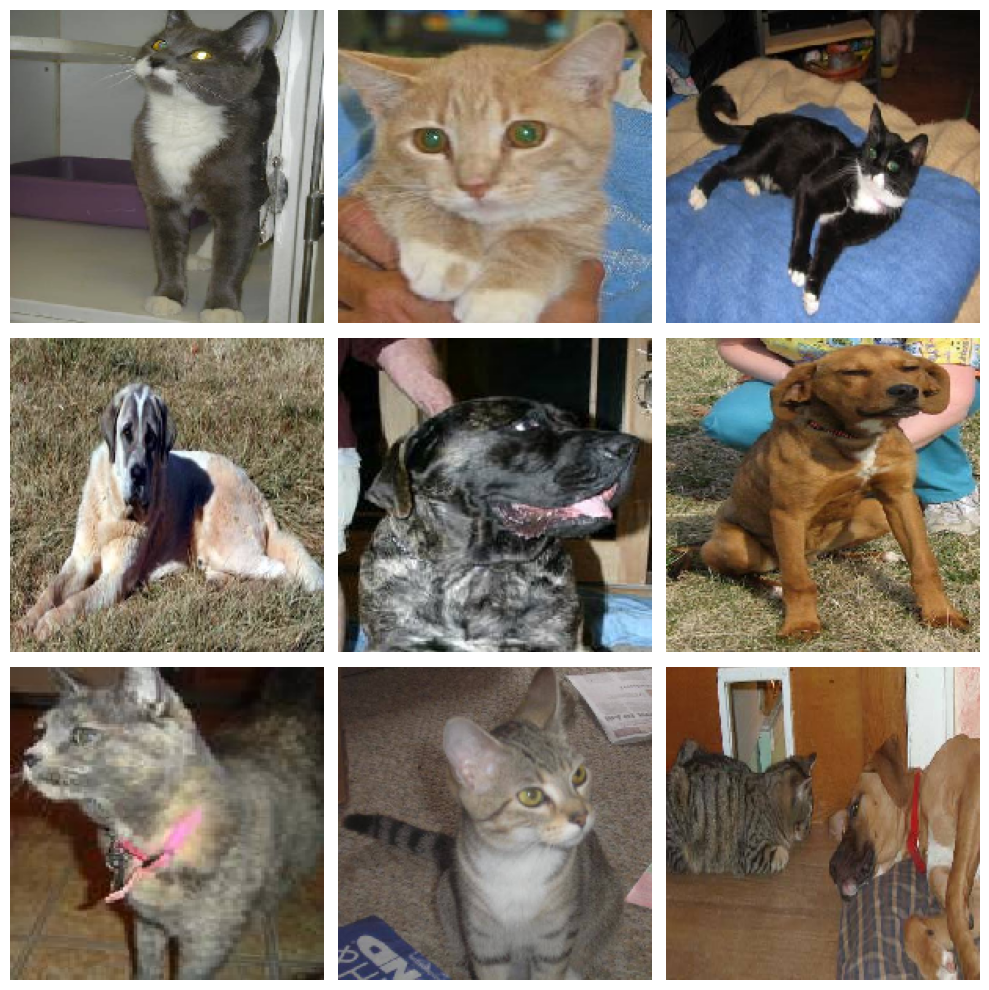

In [ ]:
# Obtener un lote del generador
images, labels = next(train_generator)  # siguiente lote

# Mostrar las primeras 9 imágenes
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

### Test

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

# Cargar imágenes desde el directorio de validación/test
test_generator = test_datagen.flow_from_directory(
    data_dir_test,
    target_size=(200, 200),
    batch_size=32,
    class_mode='categorical',   # Usa el mismo class_mode que en entrenamiento
    shuffle=False,              # ¡Importante para evaluar o predecir!
    seed=seed
)

Found 5000 images belonging to 2 classes.


## Generación y ajuste del modelo

### Arquitectura VGG16

In [ ]:
model = Sequential()
model.add(Conv2D(input_shape = (200,200,3), filters = 64, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 64,kernel_size = (3,3),padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Conv2D(filters = 128, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 128, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Flatten())
model.add(Dense(units = 4096,activation = "relu"))
model.add(Dense(units = 4096,activation = "relu"))
model.add(Dense(units = 2, activation = "softmax"))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(loss = "categorical_crossentropy", optimizer = "adam", metrics = ["accuracy"])
model

<Sequential name=sequential, built=True>

In [ ]:
model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=1
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


176/500 ━━━━━━━━━━━━━━━━━━━━ 1:05:14 12s/step - accuracy: 0.5155 - loss: 0.8910

KeyboardInterrupt: 